# Detección de phishing con regresión logística y KNN
Este cuaderno implementa desde cero dos clasificadores binarios (regresión logística y K-Nearest Neighbours) sobre el dataset `dataset_phishing.csv`, cumpliendo con las restricciones de usar únicamente `numpy`, `pandas` y `matplotlib`.

## 1. Carga y exploración del dataset de phishing
En esta sección cargamos el CSV crudo, eliminamos columnas irrelevantes como la URL y analizamos el tamaño del conjunto y el balance entre sitios legítimos y de phishing.

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

plt.style.use('seaborn-v0_8-darkgrid')
RANDOM_SEED = 42

# Carga y limpieza básica
df = pd.read_csv('dataset_phishing.csv')
if 'url' in df.columns:
    df = df.drop(columns=['url'])

label_map = {'legitimate': 0, 'phishing': 1}
df['status'] = df['status'].map(label_map)

rows, cols = df.shape
class_breakdown = df['status'].value_counts().rename(index={0: 'legitimate', 1: 'phishing'})

print(f'Tamaño del dataset: {rows} filas x {cols} columnas')
print('Distribución de clases:')
print(class_breakdown)
df.head()

Tamaño del dataset: 11430 filas x 88 columnas
Distribución de clases:
status
legitimate    5715
phishing      5715
Name: count, dtype: int64


,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,nb_eq,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,37,19,0,3,0,0,0,0,0,0,...,0,1,0,45,-1,0,1,1,4,0
1,77,23,1,1,0,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,1
2,126,50,1,4,1,0,1,2,0,3,...,1,0,0,14,4004,5828815,0,1,0,1
3,18,11,0,2,0,0,0,0,0,0,...,1,0,0,62,-1,107721,0,0,3,0
4,55,15,0,2,2,0,0,0,0,0,...,0,1,0,224,8175,8725,0,0,6,0


## 2. Selección de dos características y normalización
Calculamos la correlación de cada atributo con la etiqueta, nos quedamos con las dos variables más informativas y aplicamos normalización tipo *z-score* usando exclusivamente estadísticas del conjunto de entrenamiento.

In [2]:
def train_test_split_manual(X, y, test_size=0.2, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    m = X.shape[0]
    indices = np.arange(m)
    rng.shuffle(indices)
    test_count = int(m * test_size)
    test_idx = indices[:test_count]
    train_idx = indices[test_count:]
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

numeric_corr = df.corr(numeric_only=True)['status'].abs().sort_values(ascending=False)
feature_names = numeric_corr.index[1:3].tolist()

X = df[feature_names].to_numpy(dtype=np.float64)
y = df['status'].to_numpy(dtype=np.int64)

X_train_raw, X_test_raw, y_train, y_test = train_test_split_manual(X, y, test_size=0.2)

mean_train = X_train_raw.mean(axis=0)
std_train = X_train_raw.std(axis=0)
std_train[std_train == 0] = 1.0

X_train = (X_train_raw - mean_train) / std_train
X_test = (X_test_raw - mean_train) / std_train
X_all_scaled = (X - mean_train) / std_train

print('Features seleccionadas:', feature_names)
print('Dimensiones -> X_train:', X_train.shape, '| X_test:', X_test.shape)

Features seleccionadas: ['google_index', 'page_rank']
Dimensiones -> X_train: (9144, 2) | X_test: (2286, 2)


## 3. Implementación de la sigmoide y la hipótesis logística
Definimos funciones vectorizadas para $g(z) = \frac{1}{1 + e^{-z}}$ y la hipótesis $\hat{y} = g(Xw + b)$, además de un helper para convertir probabilidades en etiquetas binarias usando un umbral configurable.

In [3]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def predict_proba(X, w, b):
    return sigmoid(X @ w + b)

def predict_labels(X, w, b, threshold=0.5):
    return (predict_proba(X, w, b) >= threshold).astype(int)

sigmoid(np.array([-2.0, 0.0, 2.0]))

array([0.11920292, 0.5       , 0.88079708])

## 4. Costo log loss y gradientes matriciales
El costo se define como la binary cross-entropy
$$J(w,b) = -\frac{1}{m}\sum_{i=1}^{m}\Big[y^{(i)}\log(\hat{y}^{(i)}) + (1-y^{(i)})\log(1-\hat{y}^{(i)})\Big]$$
y sus gradientes se obtienen derivando respecto a $w$ y $b$ empleando álgebra matricial.

In [4]:
def log_loss(y_true, y_prob, eps=1e-9):
    y_prob = np.clip(y_prob, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_prob) + (1 - y_true) * np.log(1 - y_prob))

def compute_gradients(X, y, w, b):
    m = X.shape[0]
    y_hat = predict_proba(X, w, b)
    error = y_hat - y
    grad_w = (X.T @ error) / m
    grad_b = np.mean(error)
    return grad_w, grad_b, y_hat

w_dummy = np.zeros(X_train.shape[1])
gradients = compute_gradients(X_train, y_train, w_dummy, 0.0)
print('Gradiente inicial w:', gradients[0])

Gradiente inicial w: [-0.3669399   0.25443148]


## 5. Entrenamiento con descenso del gradiente y curva de costo
Entrenamos el modelo actualizando $w$ y $b$ en cada época, almacenamos el historial de la pérdida y monitoreamos convergencia. Finalmente graficamos la evolución del costo.

In [5]:
def gradient_descent(X, y, lr=0.1, epochs=4000):
    w = np.zeros(X.shape[1], dtype=np.float64)
    b = 0.0
    history = []
    for epoch in range(epochs):
        grad_w, grad_b, y_hat = compute_gradients(X, y, w, b)
        w -= lr * grad_w
        b -= lr * grad_b
        cost = log_loss(y, y_hat)
        history.append(cost)
        if (epoch + 1) % 500 == 0:
            print(f'Epoca {epoch + 1:4d} | Costo: {cost:.4f}')
    return w, b, history

def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

learning_rate = 0.1
epochs = 4000

weights_lr, bias_lr, cost_history = gradient_descent(X_train, y_train, lr=learning_rate, epochs=epochs)

train_preds = predict_labels(X_train, weights_lr, bias_lr)
test_preds = predict_labels(X_test, weights_lr, bias_lr)

print(f'Accuracy entrenamiento: {accuracy(y_train, train_preds):.4f}')
print(f'Accuracy prueba: {accuracy(y_test, test_preds):.4f}')

Epoca  500 | Costo: 0.3326
Epoca 1000 | Costo: 0.3326
Epoca 1500 | Costo: 0.3326
Epoca 2000 | Costo: 0.3326
Epoca 2500 | Costo: 0.3326
Epoca 3000 | Costo: 0.3326
Epoca 3500 | Costo: 0.3326
Epoca 4000 | Costo: 0.3326
Accuracy entrenamiento: 0.8663
Accuracy prueba: 0.8648


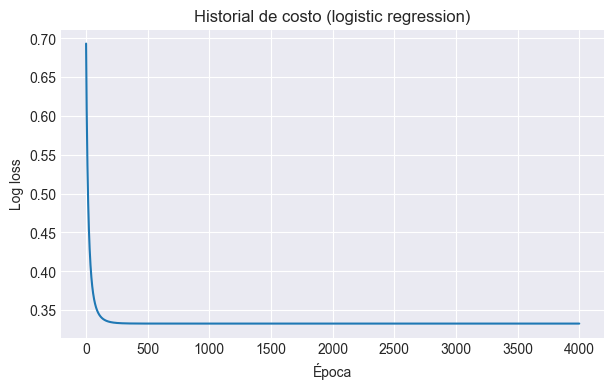

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(cost_history, color='#1f78b4')
ax.set_title('Historial de costo (logistic regression)')
ax.set_xlabel('Época')
ax.set_ylabel('Log loss')
ax.grid(True)
plt.show()

## 6. Visualización de la frontera logística en 2D
Generamos un scatter plot de las dos características (estandarizadas) coloreando observaciones legítimas y de phishing, y trazamos la recta $Xw + b = 0$ aprendida por la regresión logística como umbral de decisión.

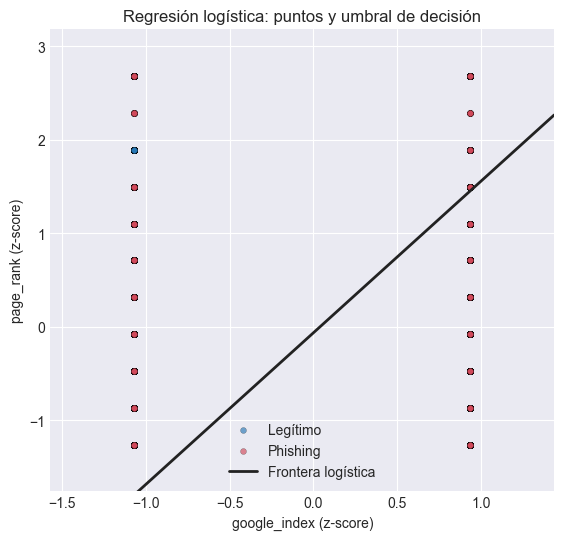

In [7]:
fig, ax = plt.subplots(figsize=(6.5, 6))
colors = {0: '#2878B5', 1: '#D1495B'}

for label in (0, 1):
    mask = y == label
    ax.scatter(
        X_all_scaled[mask, 0],
        X_all_scaled[mask, 1],
        label='Legítimo' if label == 0 else 'Phishing',
        color=colors[label],
        alpha=0.65,
        edgecolor='k',
        linewidths=0.2,
        s=18
    )

x_limits = (X_all_scaled[:, 0].min() - 0.5, X_all_scaled[:, 0].max() + 0.5)
x_vals = np.linspace(*x_limits, 200)

if np.isclose(weights_lr[1], 0.0):
    ax.axvline(x=-bias_lr / weights_lr[0], color='#222222', linewidth=2.0, label='Frontera logística')
else:
    y_vals = -(weights_lr[0] * x_vals + bias_lr) / weights_lr[1]
    ax.plot(x_vals, y_vals, color='#222222', linewidth=2.0, label='Frontera logística')

ax.set_xlim(x_limits)
ax.set_ylim(X_all_scaled[:, 1].min() - 0.5, X_all_scaled[:, 1].max() + 0.5)
ax.set_xlabel(f'{feature_names[0]} (z-score)')
ax.set_ylabel(f'{feature_names[1]} (z-score)')
ax.set_title('Regresión logística: puntos y umbral de decisión')
ax.legend()
plt.show()

## 7. Implementación manual de `predict_knn`
Construimos una función que calcula distancias euclidianas entre cada punto de consulta y el conjunto de entrenamiento, selecciona los $k$ vecinos más cercanos y devuelve la clase mayoritaria (binaria) sin recurrir a `sklearn`.

In [8]:
def predict_knn(X_train, y_train, X_test, k=3, chunk_size=256):
    if k <= 0:
        raise ValueError('k debe ser positivo')
    preds = np.empty(X_test.shape[0], dtype=np.int64)
    for start in range(0, X_test.shape[0], chunk_size):
        end = start + chunk_size
        chunk = X_test[start:end]
        diffs = chunk[:, None, :] - X_train[None, :, :]
        distances = np.sqrt(np.sum(diffs ** 2, axis=2))
        nearest_idx = np.argpartition(distances, kth=min(k, distances.shape[1]) - 1, axis=1)[:, :k]
        neighbor_labels = y_train[nearest_idx]
        votes = neighbor_labels.sum(axis=1)
        preds[start:end] = (votes >= (k / 2)).astype(int)
    return preds

# Prueba rápida: usar un subconjunto mínimo
print('Predicción de ejemplo (primeros 5 puntos de test):')
print(predict_knn(X_train[:200], y_train[:200], X_test[:5], k=3))

Predicción de ejemplo (primeros 5 puntos de test):
[1 0 1 1 0]


## 8. Evaluación de KNN con $k=3$ y mapa de decisión
Aplicamos la función anterior sobre el conjunto de prueba, reportamos la precisión y dibujamos un mapa de calor/colores con la frontera de decisión inducida por KNN sobre el plano 2D, superponiendo los datos reales.

In [9]:
K = 3
knn_test_preds = predict_knn(X_train, y_train, X_test, k=K)
knn_accuracy = accuracy(y_test, knn_test_preds)
print(f'Accuracy de KNN (k={K}) en prueba: {knn_accuracy:.4f}')

Accuracy de KNN (k=3) en prueba: 0.8491


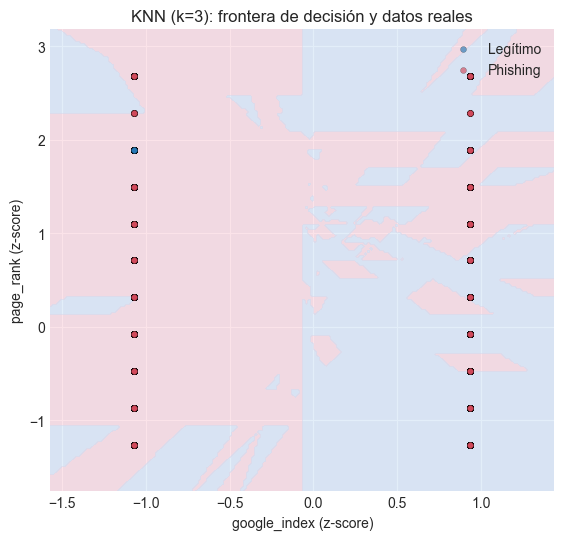

In [10]:
grid_x = np.linspace(X_all_scaled[:, 0].min() - 0.5, X_all_scaled[:, 0].max() + 0.5, 180)
grid_y = np.linspace(X_all_scaled[:, 1].min() - 0.5, X_all_scaled[:, 1].max() + 0.5, 180)
XX, YY = np.meshgrid(grid_x, grid_y)
mesh_points = np.c_[XX.ravel(), YY.ravel()]
mesh_pred = predict_knn(X_train, y_train, mesh_points, k=K, chunk_size=300)
Z = mesh_pred.reshape(XX.shape)

fig, ax = plt.subplots(figsize=(6.5, 6))
ax.contourf(XX, YY, Z, levels=[-0.5, 0.5, 1.5], colors=['#f8c9d4', '#c8def4'], alpha=0.5)

for label in (0, 1):
    mask = y == label
    ax.scatter(
        X_all_scaled[mask, 0],
        X_all_scaled[mask, 1],
        color=colors[label],
        alpha=0.65,
        edgecolor='k',
        linewidths=0.2,
        s=18,
        label='Legítimo' if label == 0 else 'Phishing'
    )

ax.set_title('KNN (k=3): frontera de decisión y datos reales')
ax.set_xlabel(f'{feature_names[0]} (z-score)')
ax.set_ylabel(f'{feature_names[1]} (z-score)')
ax.legend(loc='upper right')
plt.show()